# Thalamocortical Model Analysis: Global Benchmarking & Circuit Morphology

This notebook provides a multi-stage analysis of thalamocortical expansion models, comparing **probabilistic wiring-only** models at margin zero. The main difference being investigated here is the different image sizes.

In the prior experiments, we used images of size 224x224. Here, we take a step back and use smaller images of size 64x64. We initialize the models with the same LGN and V1 sizes, allowing to make comparisons where this is the only perturbation

In [1]:
import os
import glob
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import jax.numpy as jnp
import seaborn as sns
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA

from ringach_model import ringach_VVS
from utils import Utils

# Set plotting style
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

# Configuration constants
LGN_VALUES = [32, 64, 128, 256, 512, 1024]
V1_VALUES = [32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384]

MARGIN = 0
PROB_RESULTS_DIR_224 = f"results_probabilistic_margin{MARGIN}"
PROB_RESULTS_DIR_64 = f"results_probabilistic_margin{MARGIN}_patch64"

def load_pkl(path):
    if os.path.exists(path):
        with open(path, 'rb') as f:
            try: return pickle.load(f)
            except: return None
    return None

def collect_metrics(res_dir):
    metrics = []
    files = glob.glob(os.path.join(res_dir, "res_LGN*_V1*.pkl"))
    for f in files:
        data = load_pkl(f)
        if data:
            parts = os.path.basename(f).replace('.pkl', '').split('_')
            try:
                curr_lgn = int(parts[1][3:])
                curr_v1 = int(parts[2][2:])
                test_loss = data.get('test_loss', np.nan)
                if hasattr(test_loss, 'item'): test_loss = test_loss.item()
                test_viol = data.get('test_viol', np.nan)
                if hasattr(test_viol, 'item'): test_viol = test_viol.item()
                metrics.append({
                    'lgn': curr_lgn, 'v1': curr_v1, 'expansion': curr_v1 / curr_lgn,
                    'test_loss': test_loss, 'test_viol': test_viol * 100,
                    'gini': data.get('v1_gini', np.nan)
                })
            except: continue
    return pd.DataFrame(metrics).sort_values(['lgn', 'v1'])

df_prob_224 = collect_metrics(PROB_RESULTS_DIR_224)
df_prob_64 = collect_metrics(PROB_RESULTS_DIR_64)
print(f"Loaded: {len(df_prob_224)} 224x224 models, {len(df_prob_64)} 64x64 models")

Loaded: 60 224x224 models, 60 64x64 models


## 1. Global Performance Mapping: Trained vs. Probabilistic

Goal: Compare image size-based differences between probabilistic baselines across the expansion factor plane.

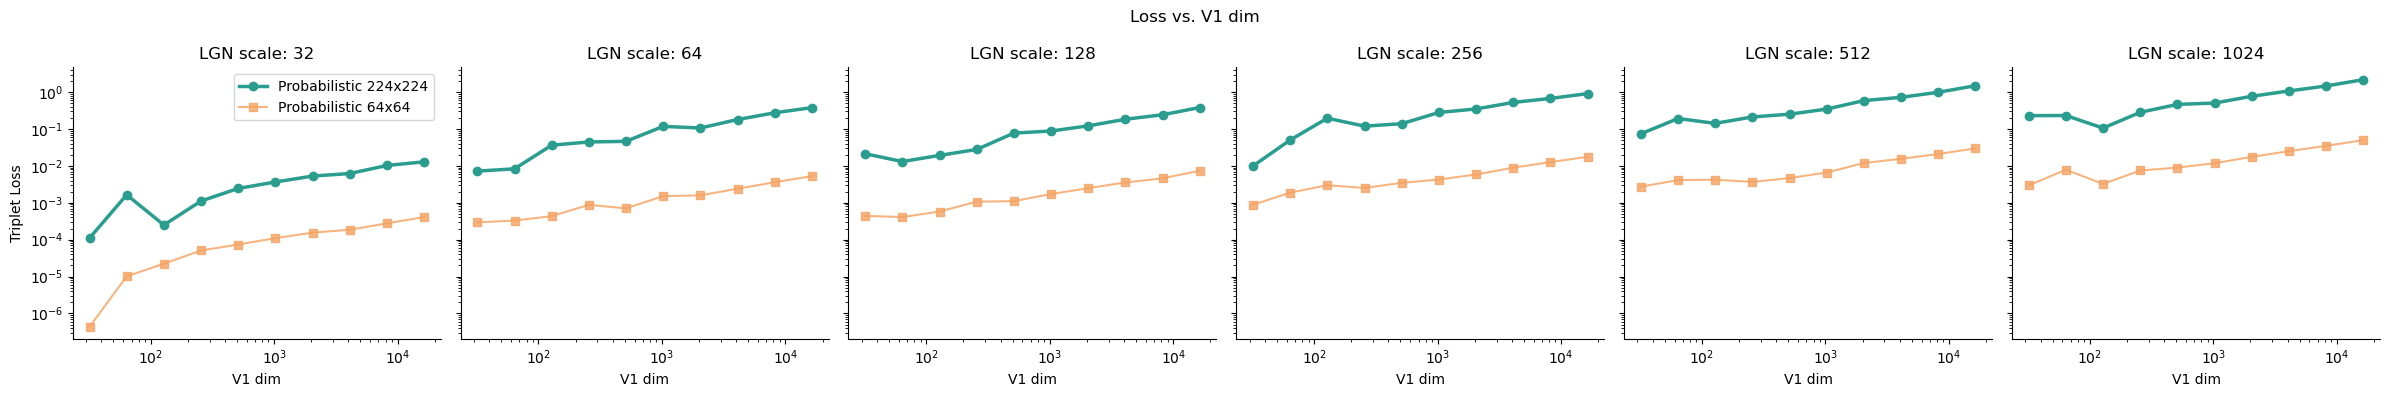

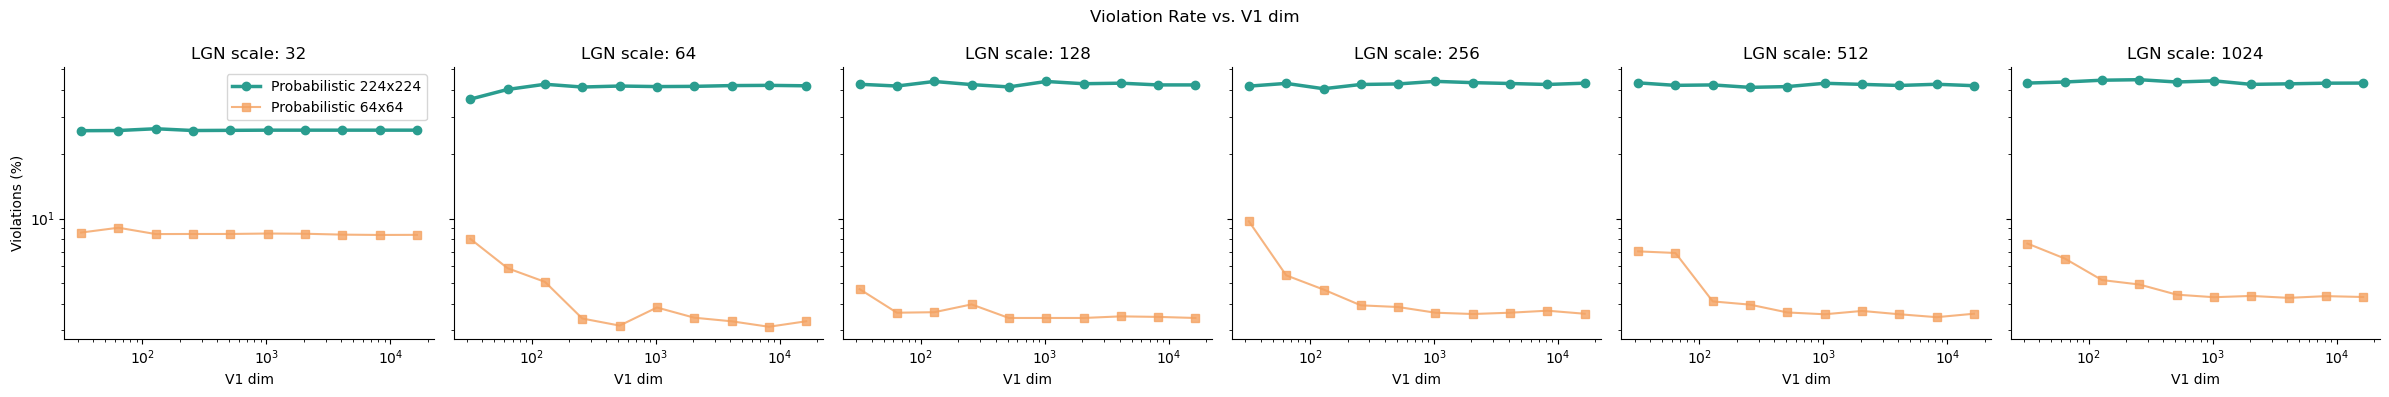

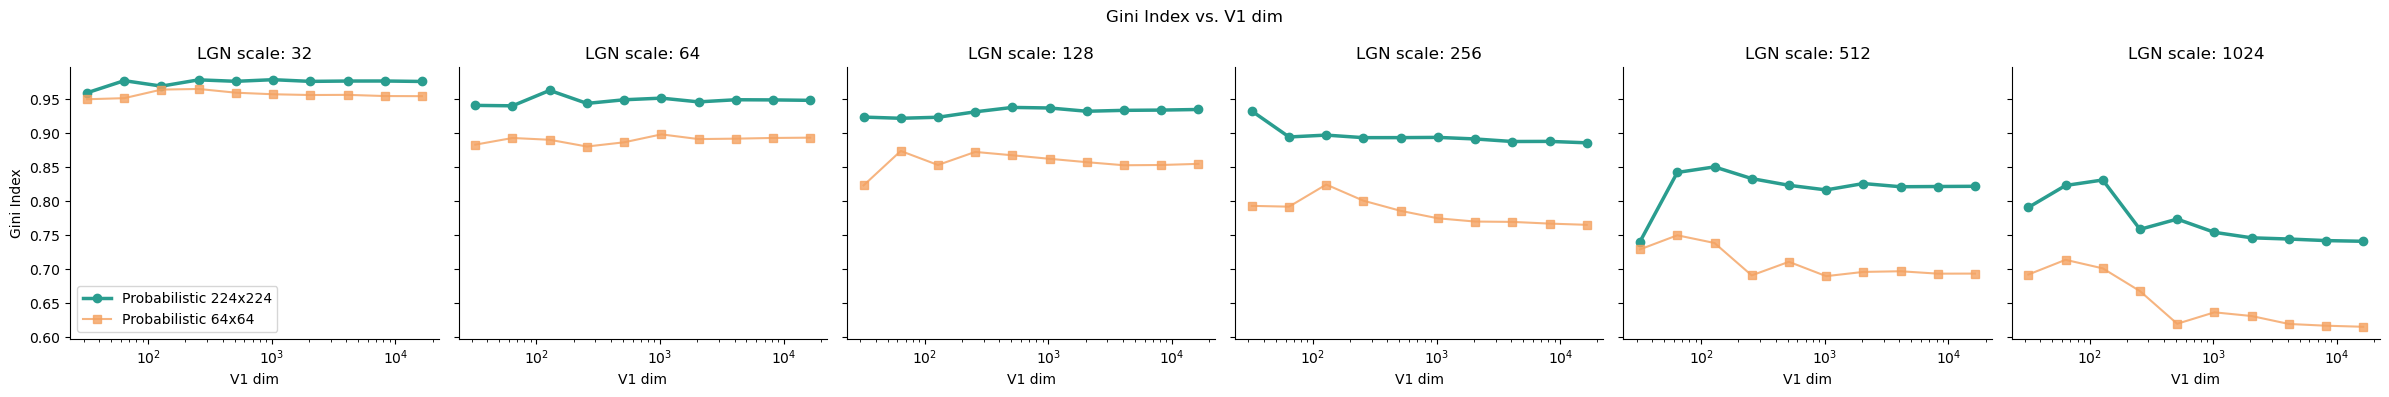

In [2]:
def plot_comparison_grid(metric_key, ylabel, title):
    fig, axes = plt.subplots(1, 6, figsize=(24, 4), sharex=True, sharey=True)
    axes = axes.flatten()
    for i, lgn in enumerate(LGN_VALUES):
        ax = axes[i]
        t_sub = df_prob_224[df_prob_224['lgn'] == lgn]
        p_sub = df_prob_64[df_prob_64['lgn'] == lgn]

        if not t_sub.empty: ax.plot(t_sub['v1'], t_sub[metric_key], 'o-', label='Probabilistic 224x224', color='#2A9D8F', linewidth=2.5)
        if not p_sub.empty: ax.plot(p_sub['v1'], p_sub[metric_key], 's-', label='Probabilistic 64x64', color='#F4A261', alpha=0.8)
        
        ax.set_title(f"LGN scale: {lgn}")
        ax.set_xscale('log')
        
        if i == 0: 
            ax.legend()
            ax.set_ylabel(ylabel)
        ax.set_xlabel("V1 dim")
        
        if metric_key in ["test_loss", "test_viol"]:
            ax.set_yscale("log")

    plt.suptitle(title)
    fig.set_tight_layout(True)
    plt.show()

plot_comparison_grid('test_loss', 'Triplet Loss', 'Loss vs. V1 dim')
plot_comparison_grid('test_viol', 'Violations (%)', 'Violation Rate vs. V1 dim')
plot_comparison_grid('gini', 'Gini Index', 'Gini Index vs. V1 dim')

## 3. Model Scaling Heatmaps

Goal: Identify scaling trends and diminishing returns in the 2D plane of population size.

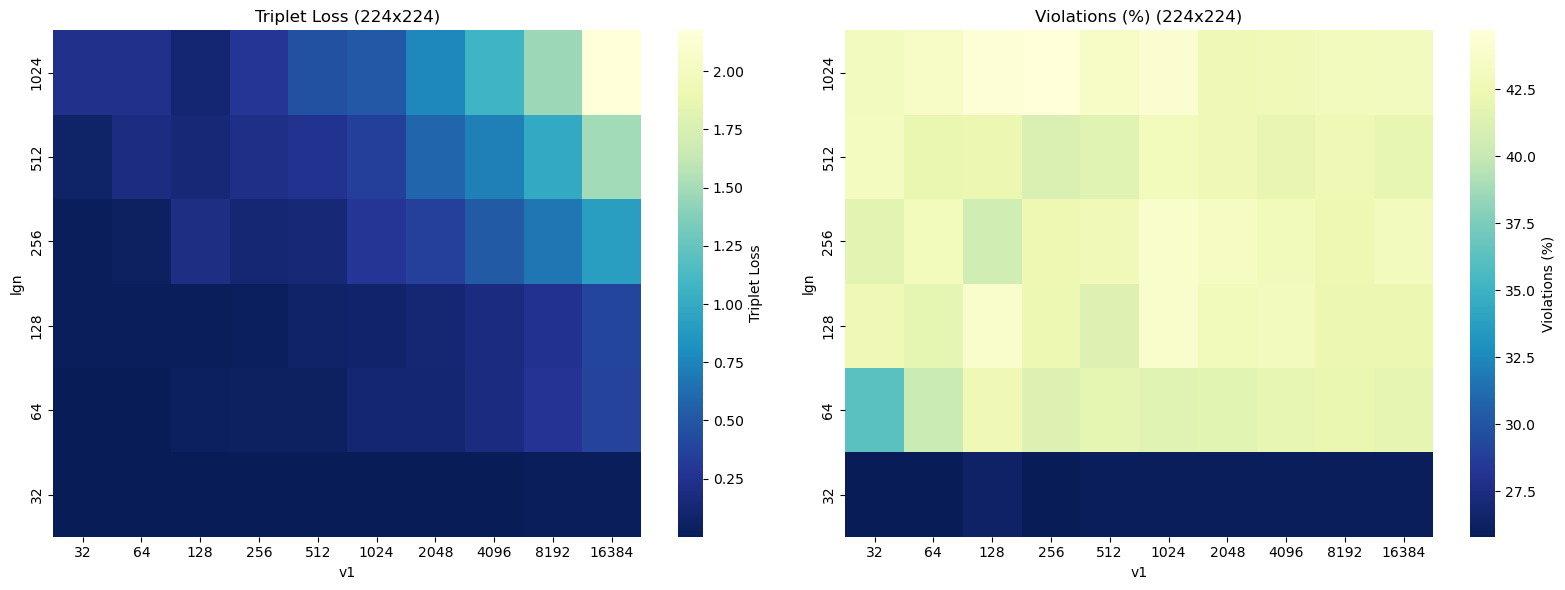

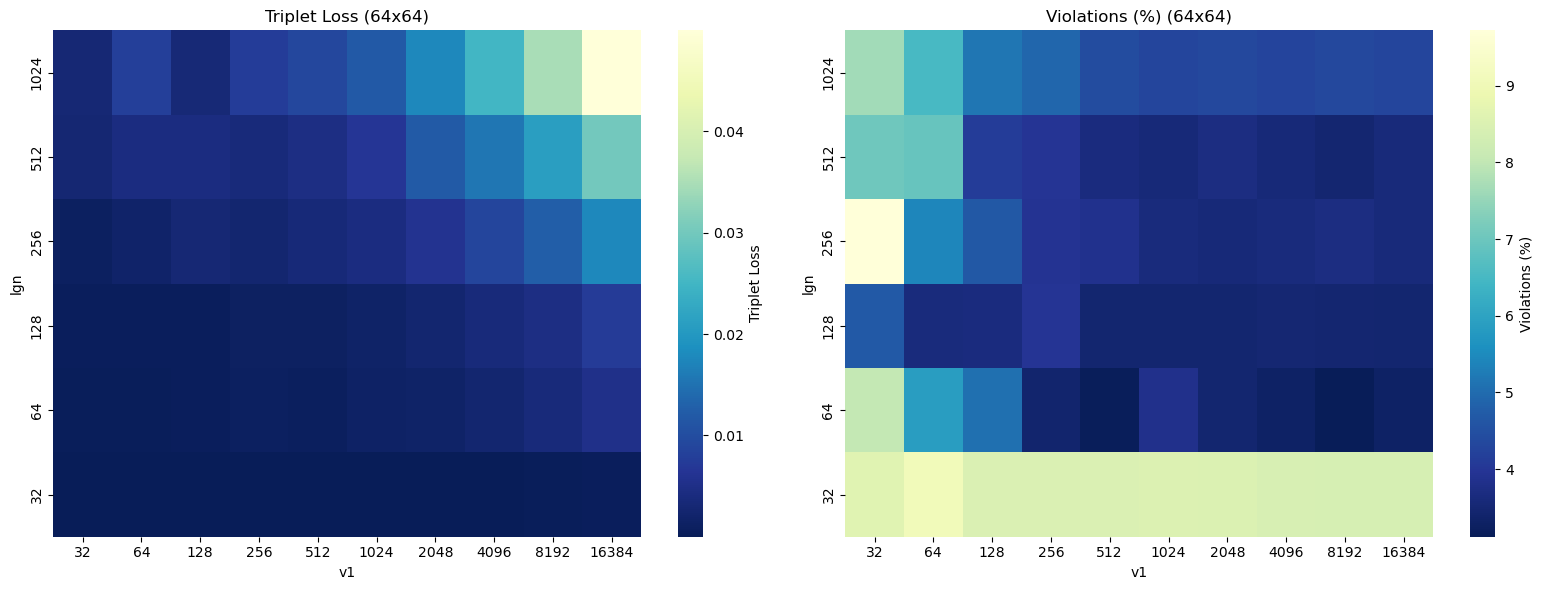

In [3]:
def plot_scaling_heatmaps(df, title_suffix):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for i, (key, label) in enumerate([('test_loss', 'Triplet Loss'), ('test_viol', 'Violations (%)')]):
        pivot = df.pivot(index='lgn', columns='v1', values=key)

        if key == "test_loss":
            sns.heatmap(pivot, annot=False, fmt=".2f", cmap="YlGnBu_r", ax=axes[i], cbar_kws={'label': label})
        else:
            sns.heatmap(pivot, annot=False, fmt=".2f", cmap="YlGnBu_r", ax=axes[i], cbar_kws={'label': label})

        axes[i].set_title(f"{label} ({title_suffix})")
        axes[i].invert_yaxis()
    plt.tight_layout()
    plt.show()

plot_scaling_heatmaps(df_prob_224, "224x224")
plot_scaling_heatmaps(df_prob_64, "64x64")

## 4. Receptive Field Visualization

We visualize V1 receptive fields by reconstructing the spatial filter from LGN synapse locations and weights.

In [4]:
def get_full_model_data(lgn, v1, trained=False, shape=(224,224)):
    np.random.seed(42)
    n_rgc = int(np.sqrt(lgn // 2.5))
    v1_d = int(np.sqrt(v1))
    model = ringach_VVS(shape=shape, n_RGC=n_rgc, v1_dim=v1_d, eta_0=[3,8])
    lgn_locs = np.concatenate([model.RGC_locs, model.RGC_locs[model.LGN_RGC_idx]])
    
    if trained:
        w = load_pkl(os.path.join(TRAIN_PARAMS_DIR, f"best_params_LGN{lgn}_V1{v1}.pkl"))
        if w is None: return None
        weights = np.array(w[:len(model.V1_locs), :len(lgn_locs)])
    else:
        weights = np.array(model.LGN_V1_conn)
        
    lgn_acts = np.array(model.RGC_activations)
    lgn_acts = np.concatenate([lgn_acts, lgn_acts[model.LGN_RGC_idx]])
    v_rf = (weights @ lgn_acts.reshape(lgn_acts.shape[0], -1)).reshape((-1, *shape))
    return model, lgn_locs, weights, v_rf

In [5]:
def visualize_rf_subset(lgn, v1, rf_size=80, trained=True, mode="representative", shape=(224,224)):

    data = get_full_model_data(lgn, v1, trained, shape=shape)
    if data is None:
        return

    model, lgn_locs, weights, v_rf = data

    rf_size = shape[0] // 3
    half = rf_size // 2
    h, w = v_rf.shape[1:]

    # --- find neurons whose RF crop will be fully inside the image ---
    valid = [] # [i for i, (cx, cy) in enumerate(model.V1_locs)]
    for i, (cx, cy) in enumerate(model.V1_locs):
        if (half <= cx <= w-half) and (half <= cy <= h-half):
            valid.append(i)

    valid = np.array(valid)

    if len(valid) < 6:
        print("Not enough valid RFs")
        #return

    # --- choose which RFs to display ---
    if mode == "top":
        variances = np.var(weights[valid], axis=1)
        indices = valid[np.argsort(variances)[-6:]][::-1]
    else:
        indices = np.random.choice(valid, 6, replace=False)

    fig, axes = plt.subplots(1, 6, figsize=(24, 4))
    threshold = 0.001

    for ax, r in zip(axes, indices):

        rf = (v_rf[r] - v_rf[r].mean()) / (v_rf[r].std() + 1e-12)

        cx, cy = model.V1_locs[r]

        x0 = int(cx - half)
        x1 = int(cx + half)
        y0 = int(cy - half)
        y1 = int(cy + half)

        rf_crop = rf[y0:y1, x0:x1]

        vmax = np.percentile(np.abs(rf_crop), 99)
        ax.imshow(rf_crop, cmap="seismic", vmin=-vmax, vmax=vmax, origin="upper")

        conn = weights[r]
        mask = conn > threshold
        aff_locs = lgn_locs[mask]

        on = aff_locs[aff_locs[:,2] == 1]
        off = aff_locs[aff_locs[:,2] == -1]

        """if len(on) > 0:
            on = on[:, :2] - np.array([x0, y0])
            ax.scatter(on[:,0], on[:,1], marker="o", c="white", edgecolors="black", s=conn[(lgn_locs[:,2]==1) & mask] * 1000)

        if len(off) > 0:
            off = off[:, :2] - np.array([x0, y0])
            ax.scatter( off[:,0], off[:,1], marker="v", c="white", edgecolors="black", s=conn[(lgn_locs[:,2]==-1) & mask] * 1000)"""

        #ax.axis("equal")
        ax.axis("off")

    label = "LEARNED (Trained)" if trained else "HAPHAZARD (Probabilistic)"
    top_label = "structured" if mode == "top" else "representative"

    fig.suptitle(f"{label} {top_label} RF Morphology (LGN={lgn}, V1={v1})", fontsize=16)
    fig.tight_layout()
    plt.show()

### 4.1 Representative Rows
Comparing structured slices of the cortical sheet across the two paradigms.

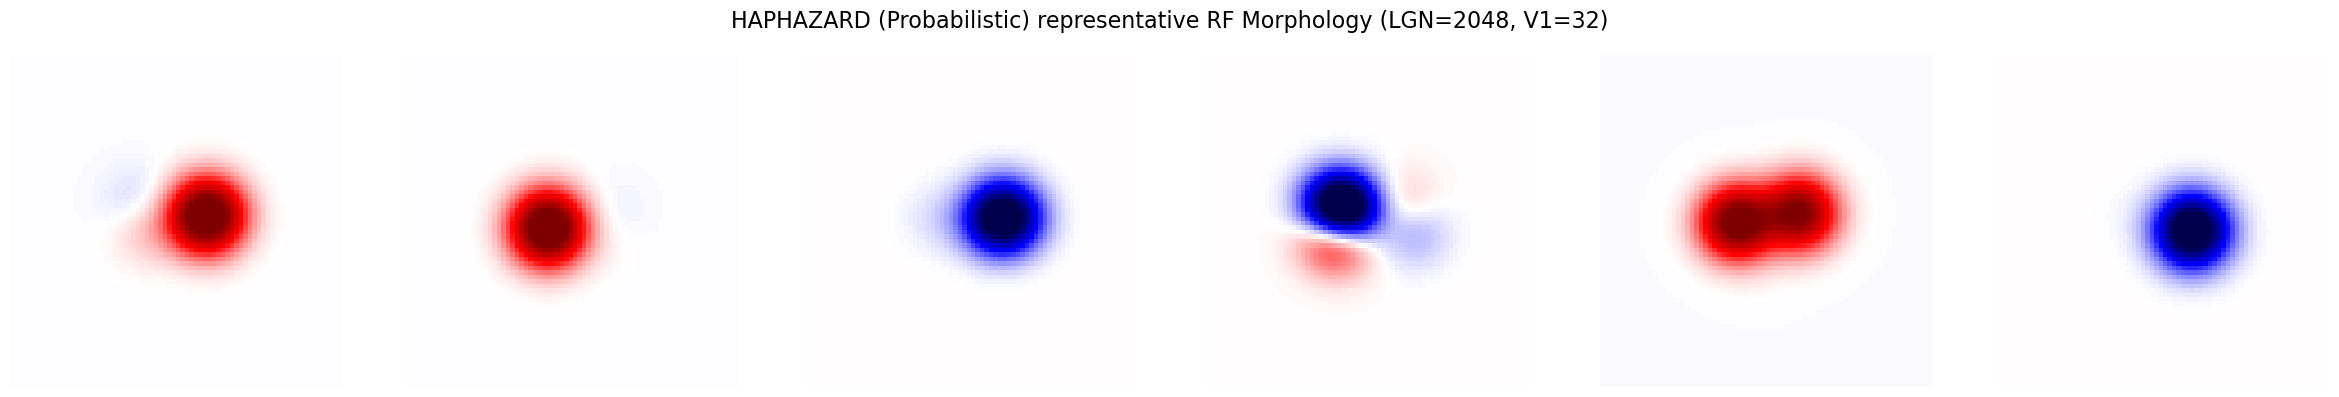

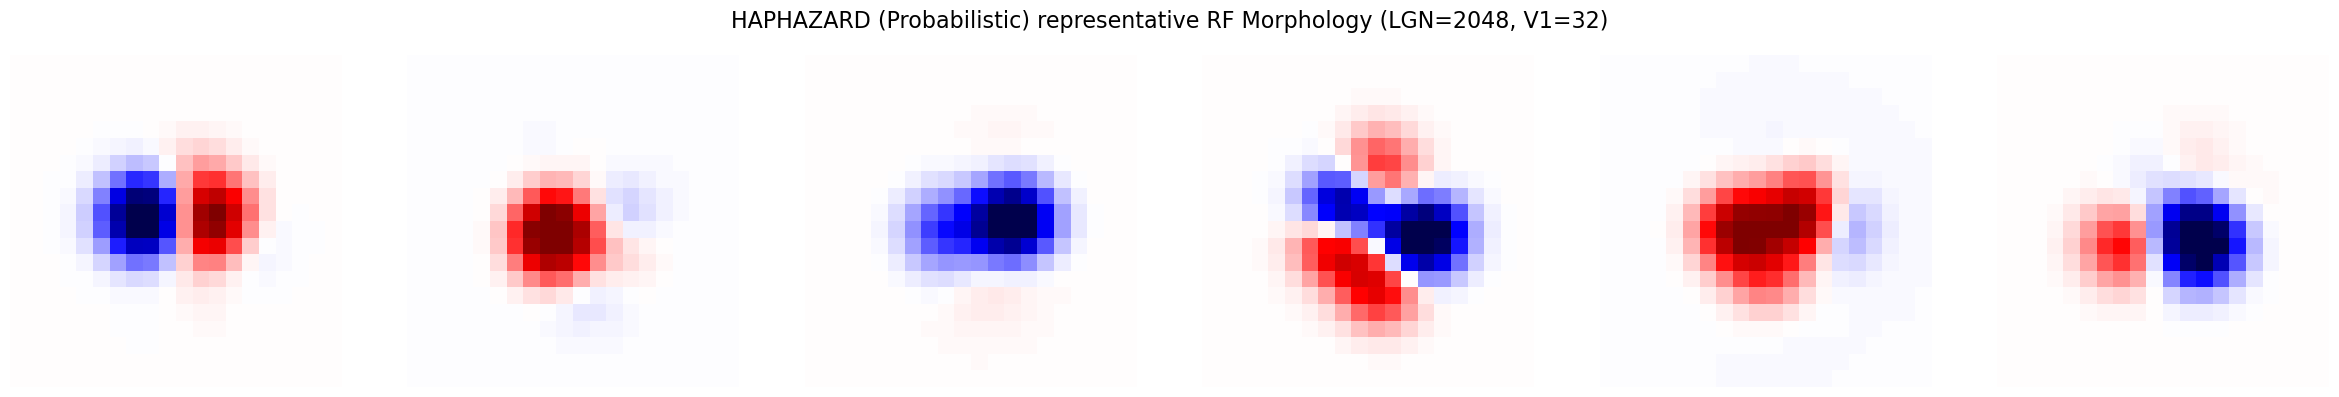

In [11]:
visualize_rf_subset(2048, 32, 80, trained=False, shape=(224,224))
visualize_rf_subset(2048, 32, 80, trained=False, shape=(64,64))
#visualize_rf_subset(1024, 32, 80, trained=True, mode='top')
#visualize_rf_subset(1024, 32, 80, trained=False, mode="top")

## 5. Connectivity Structure (LGN → V1)

Goal: Test whether trained connectivity respects spatial topography.

In [12]:
def analyze_connectivity(lgn, v1, trained, shape=(224,224)):
    data = get_full_model_data(lgn, v1, trained, shape=shape)
    if not data: return
    model, lgn_locs, weights, _ = data
    dists = cdist(model.V1_locs, lgn_locs[:, :2])
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Strength vs Distance
    idx = np.random.choice(weights.size, 5000, replace=True)
    axes[0].scatter(dists.flatten()[idx], weights.flatten()[idx], alpha=0.9, s=1, color='purple')
    axes[0].set_xlabel("Euclidean Distance (LGN to V1)")
    axes[0].set_ylabel("Weight strength")

    # Weight Distribution
    axes[1].hist(weights.flatten()[weights.flatten()>0], bins=50, color='teal', alpha=0.7)
    axes[1].set_yscale('log')
    axes[1].set_xlabel("Positive Weights")
    axes[1].set_ylabel("Frequency (Log)")

    plt.suptitle(f"Connectivity Statistics: LGN: {lgn}, V1: {v1}, trained: {trained}")
    plt.tight_layout()
    plt.show()

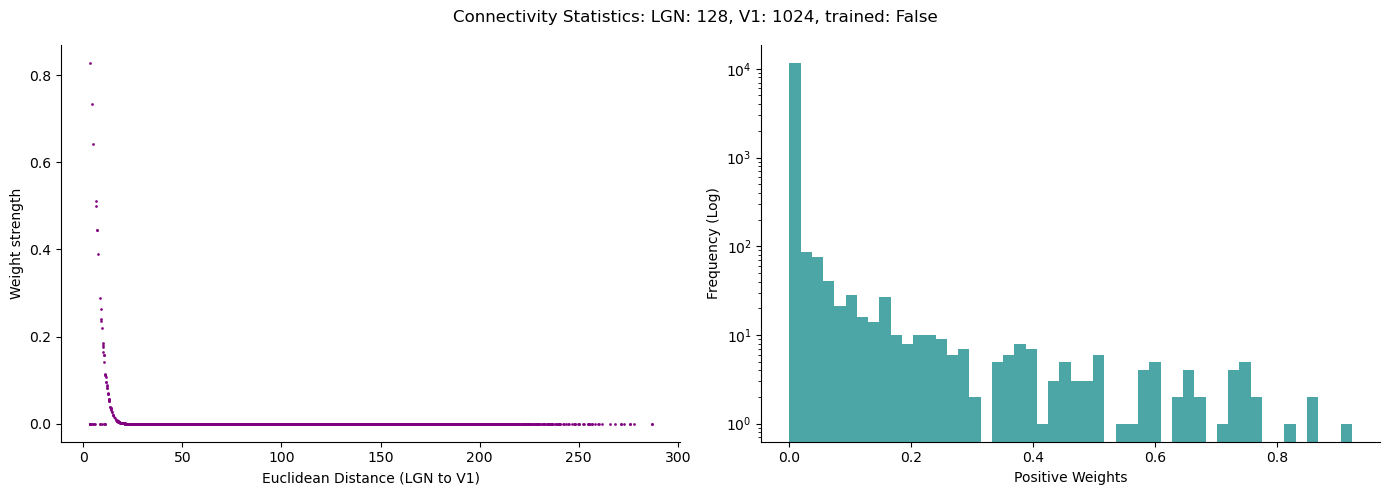

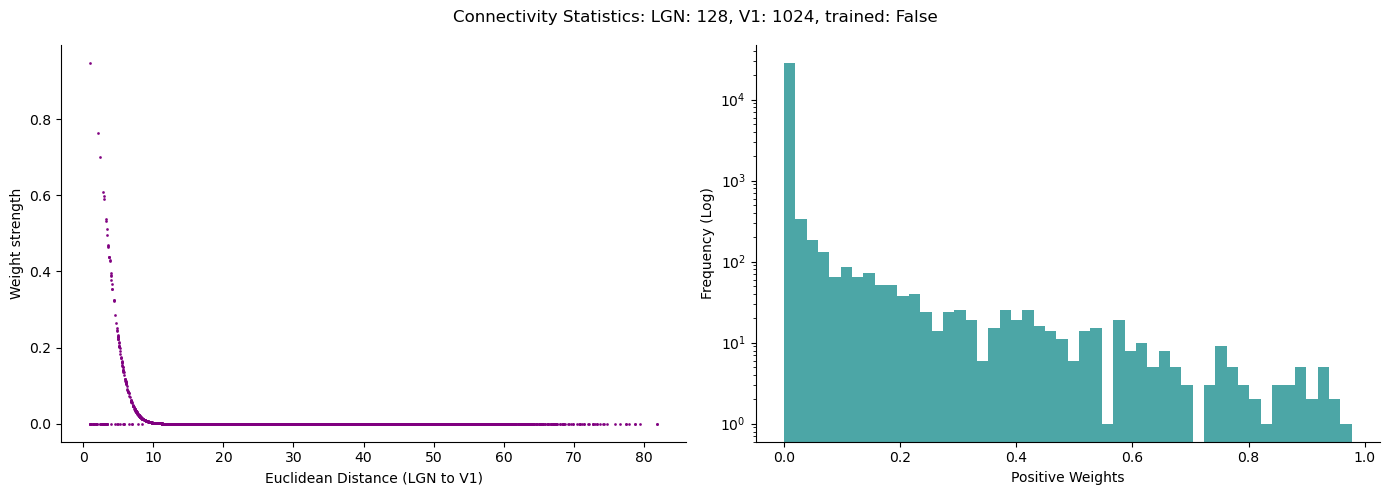

In [13]:
analyze_connectivity(128, 1024, trained=False, shape=(224,224))
analyze_connectivity(128, 1024, trained=False, shape=(64,64))

## 6. Representation Geometry

Goal: Measure how cortical expansion alters the dimensionality and similarity manifold.

In [14]:
def analyze_geometry(lgn, v1, trained, ax, stimuli, shape=(224,224)):

    # get the model
    data = get_full_model_data(lgn, v1, trained, shape=shape)
    if not data: return

    model, _, weights, _ = data

    l_res, v_res = [], []
    for i in range(100):
        _, l, v = model.forward(stimuli[i], weights=jnp.array(weights))
        l_res.append(np.array(l))
        v_res.append(np.array(v))
    L, V = np.array(l_res), np.array(v_res)

    L_pca = PCA().fit(L)
    V_pca = PCA().fit(V)
    
    ax.plot(np.cumsum(L_pca.explained_variance_ratio_), label='LGN', c='green', linestyle="--")
    ax.plot(np.cumsum(V_pca.explained_variance_ratio_), label='V1', c='green', linestyle="-")

    # compute participation ratio
    L_pr = np.sum(L_pca.explained_variance_)**2 / np.sum(L_pca.explained_variance_)
    V_pr = np.sum(V_pca.explained_variance_)**2 / np.sum(V_pca.explained_variance_)

    ax.text(60, 0.7, f"LGN PR: {L_pr:.2f}")
    ax.text(60, 0.75, f"V1 PR: {V_pr:.2f}")

    ax.set_title(f"LGN: {lgn}, V1: {v1}")
    ax.legend()

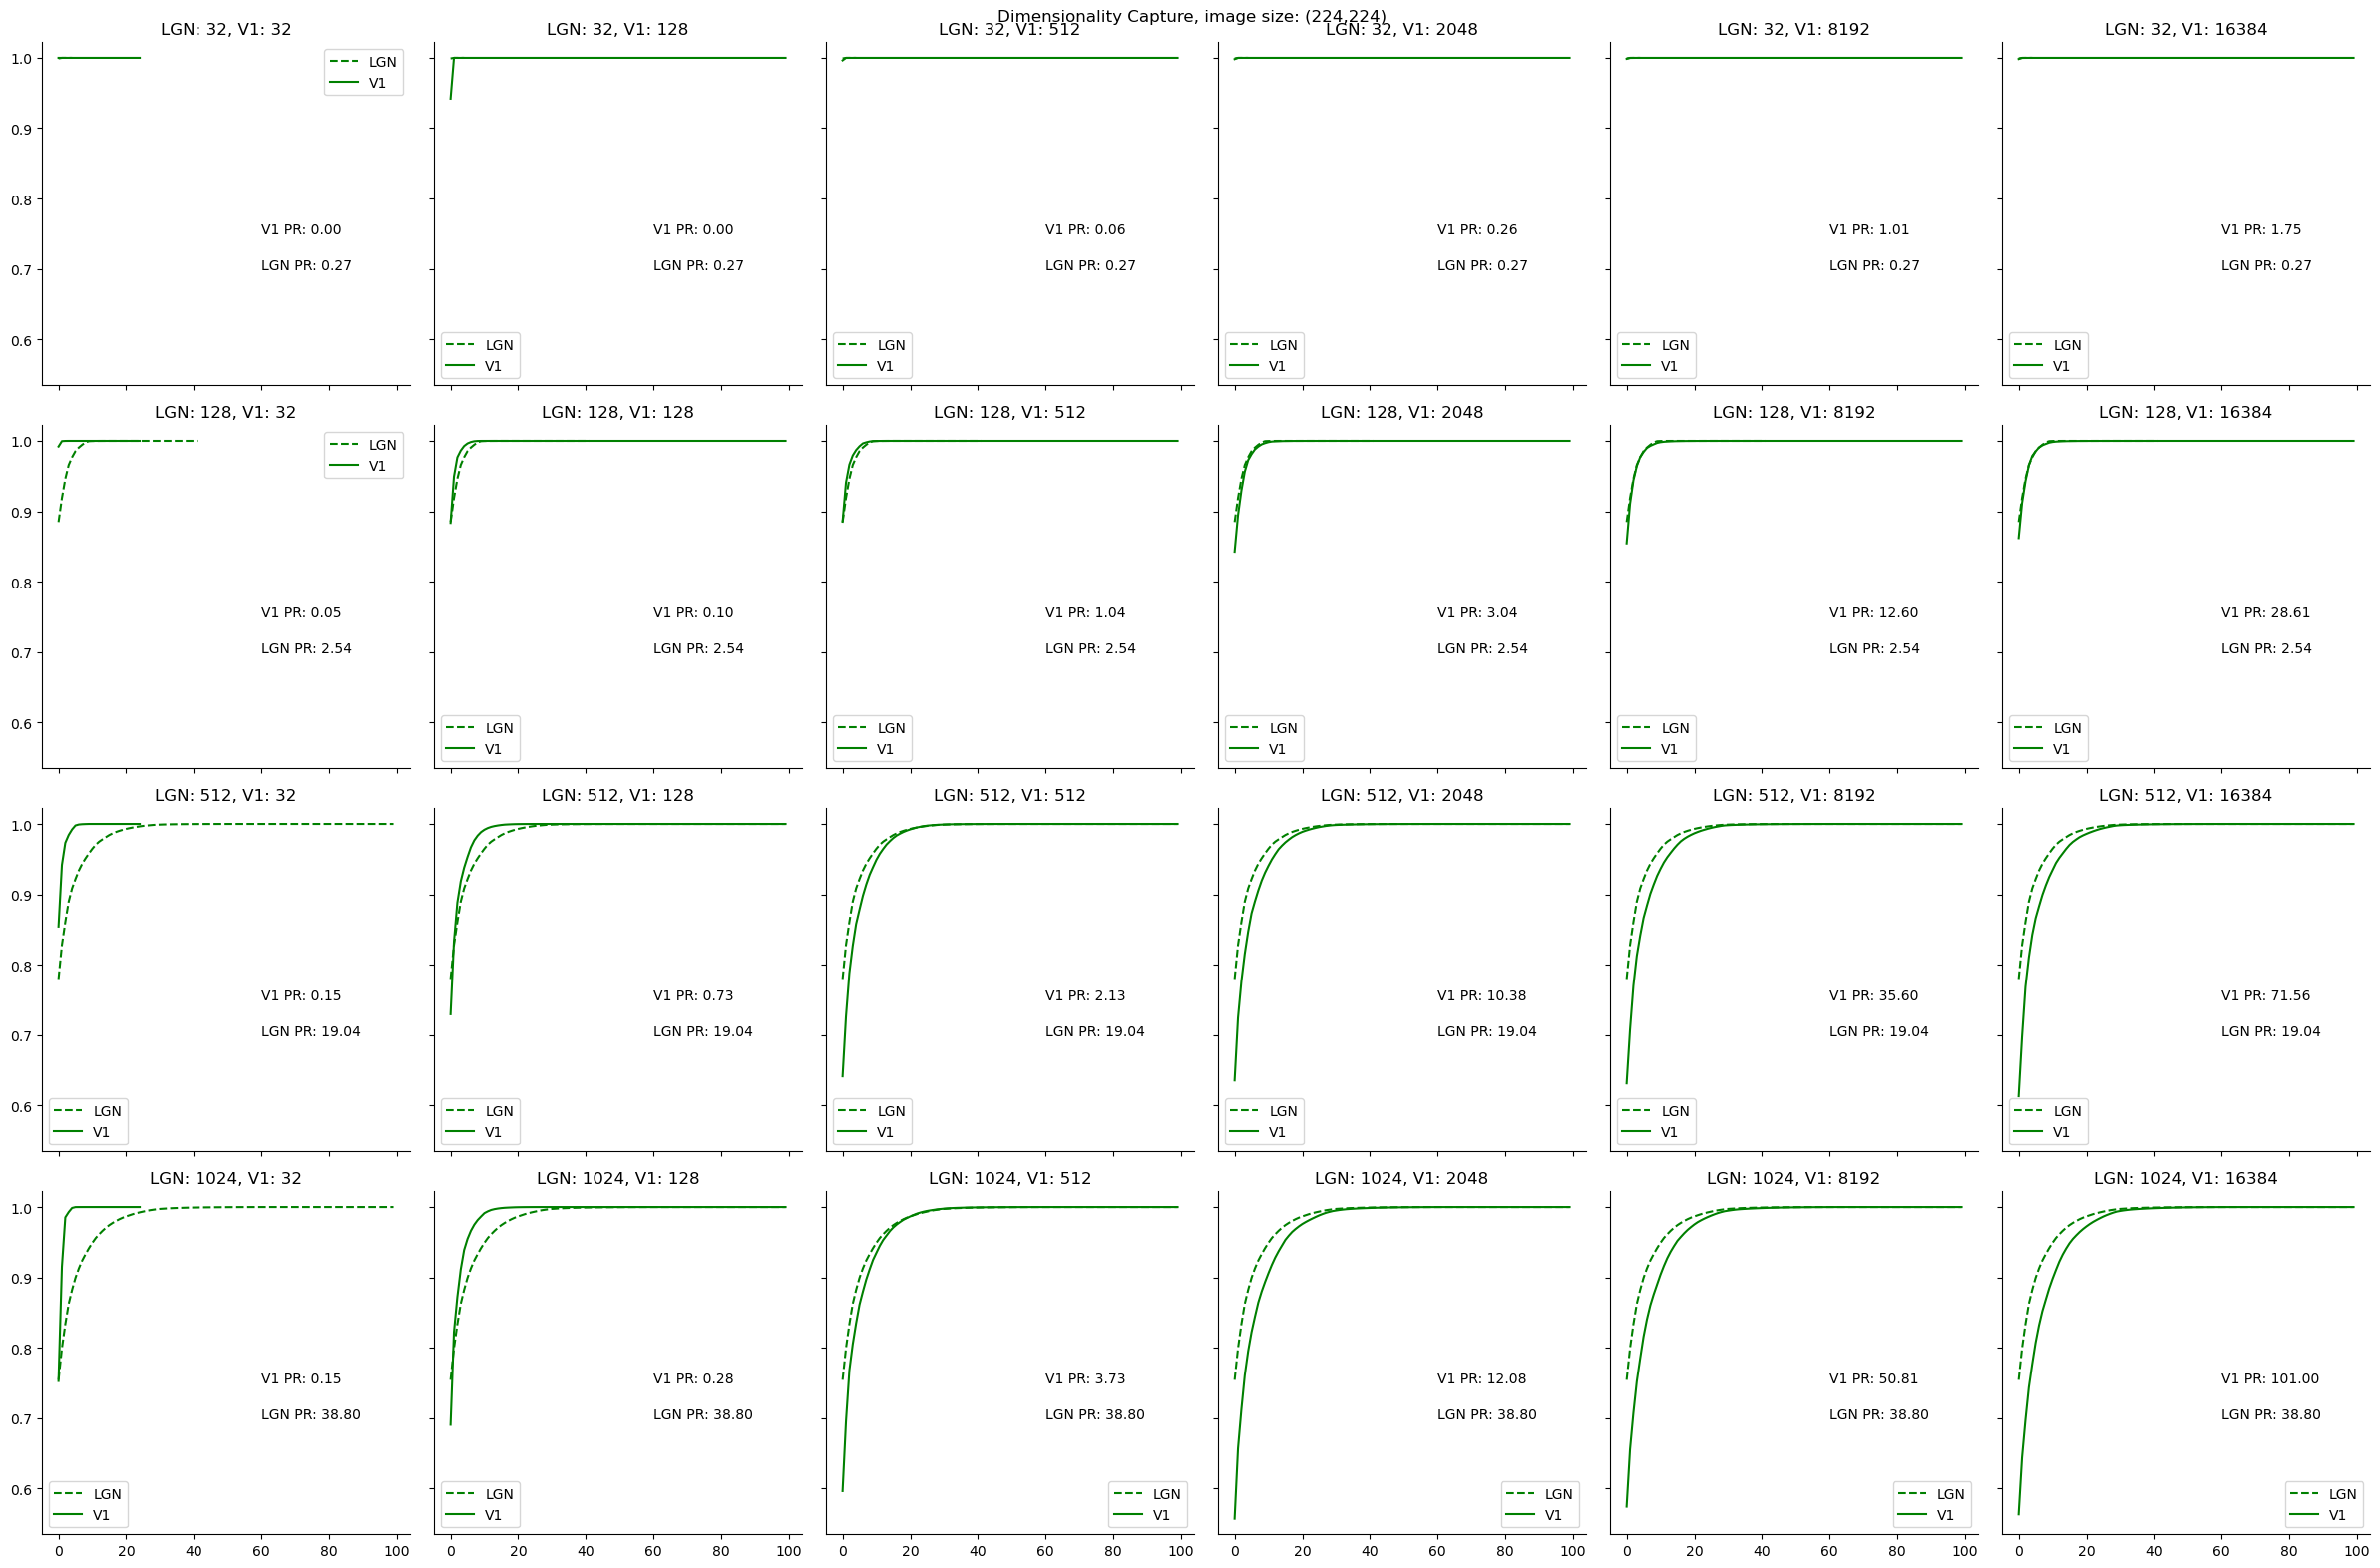

In [15]:
fig, ax = plt.subplots(4, 6, figsize=(24, 16), sharex=True, sharey=True)

l = [32, 128, 512, 1024]
v = [32, 128, 512, 2048, 8192, 16384]

stimuli = np.load("/u/home/s/skirti/scratch/dipoppa-lab/thalamocortical-expansion/01_data/natural_movies/IMG_3625_patches.npy")[:100,0]
L_pr = []

for i,a in enumerate(ax.flatten()):
    
    analyze_geometry(l[i // len(v)], v[i % len(v)], trained=False, ax=a, stimuli=stimuli, shape=(224,224))
    
fig.suptitle("Dimensionality Capture, image size: (224,224)")
fig.set_tight_layout(True)
plt.show()

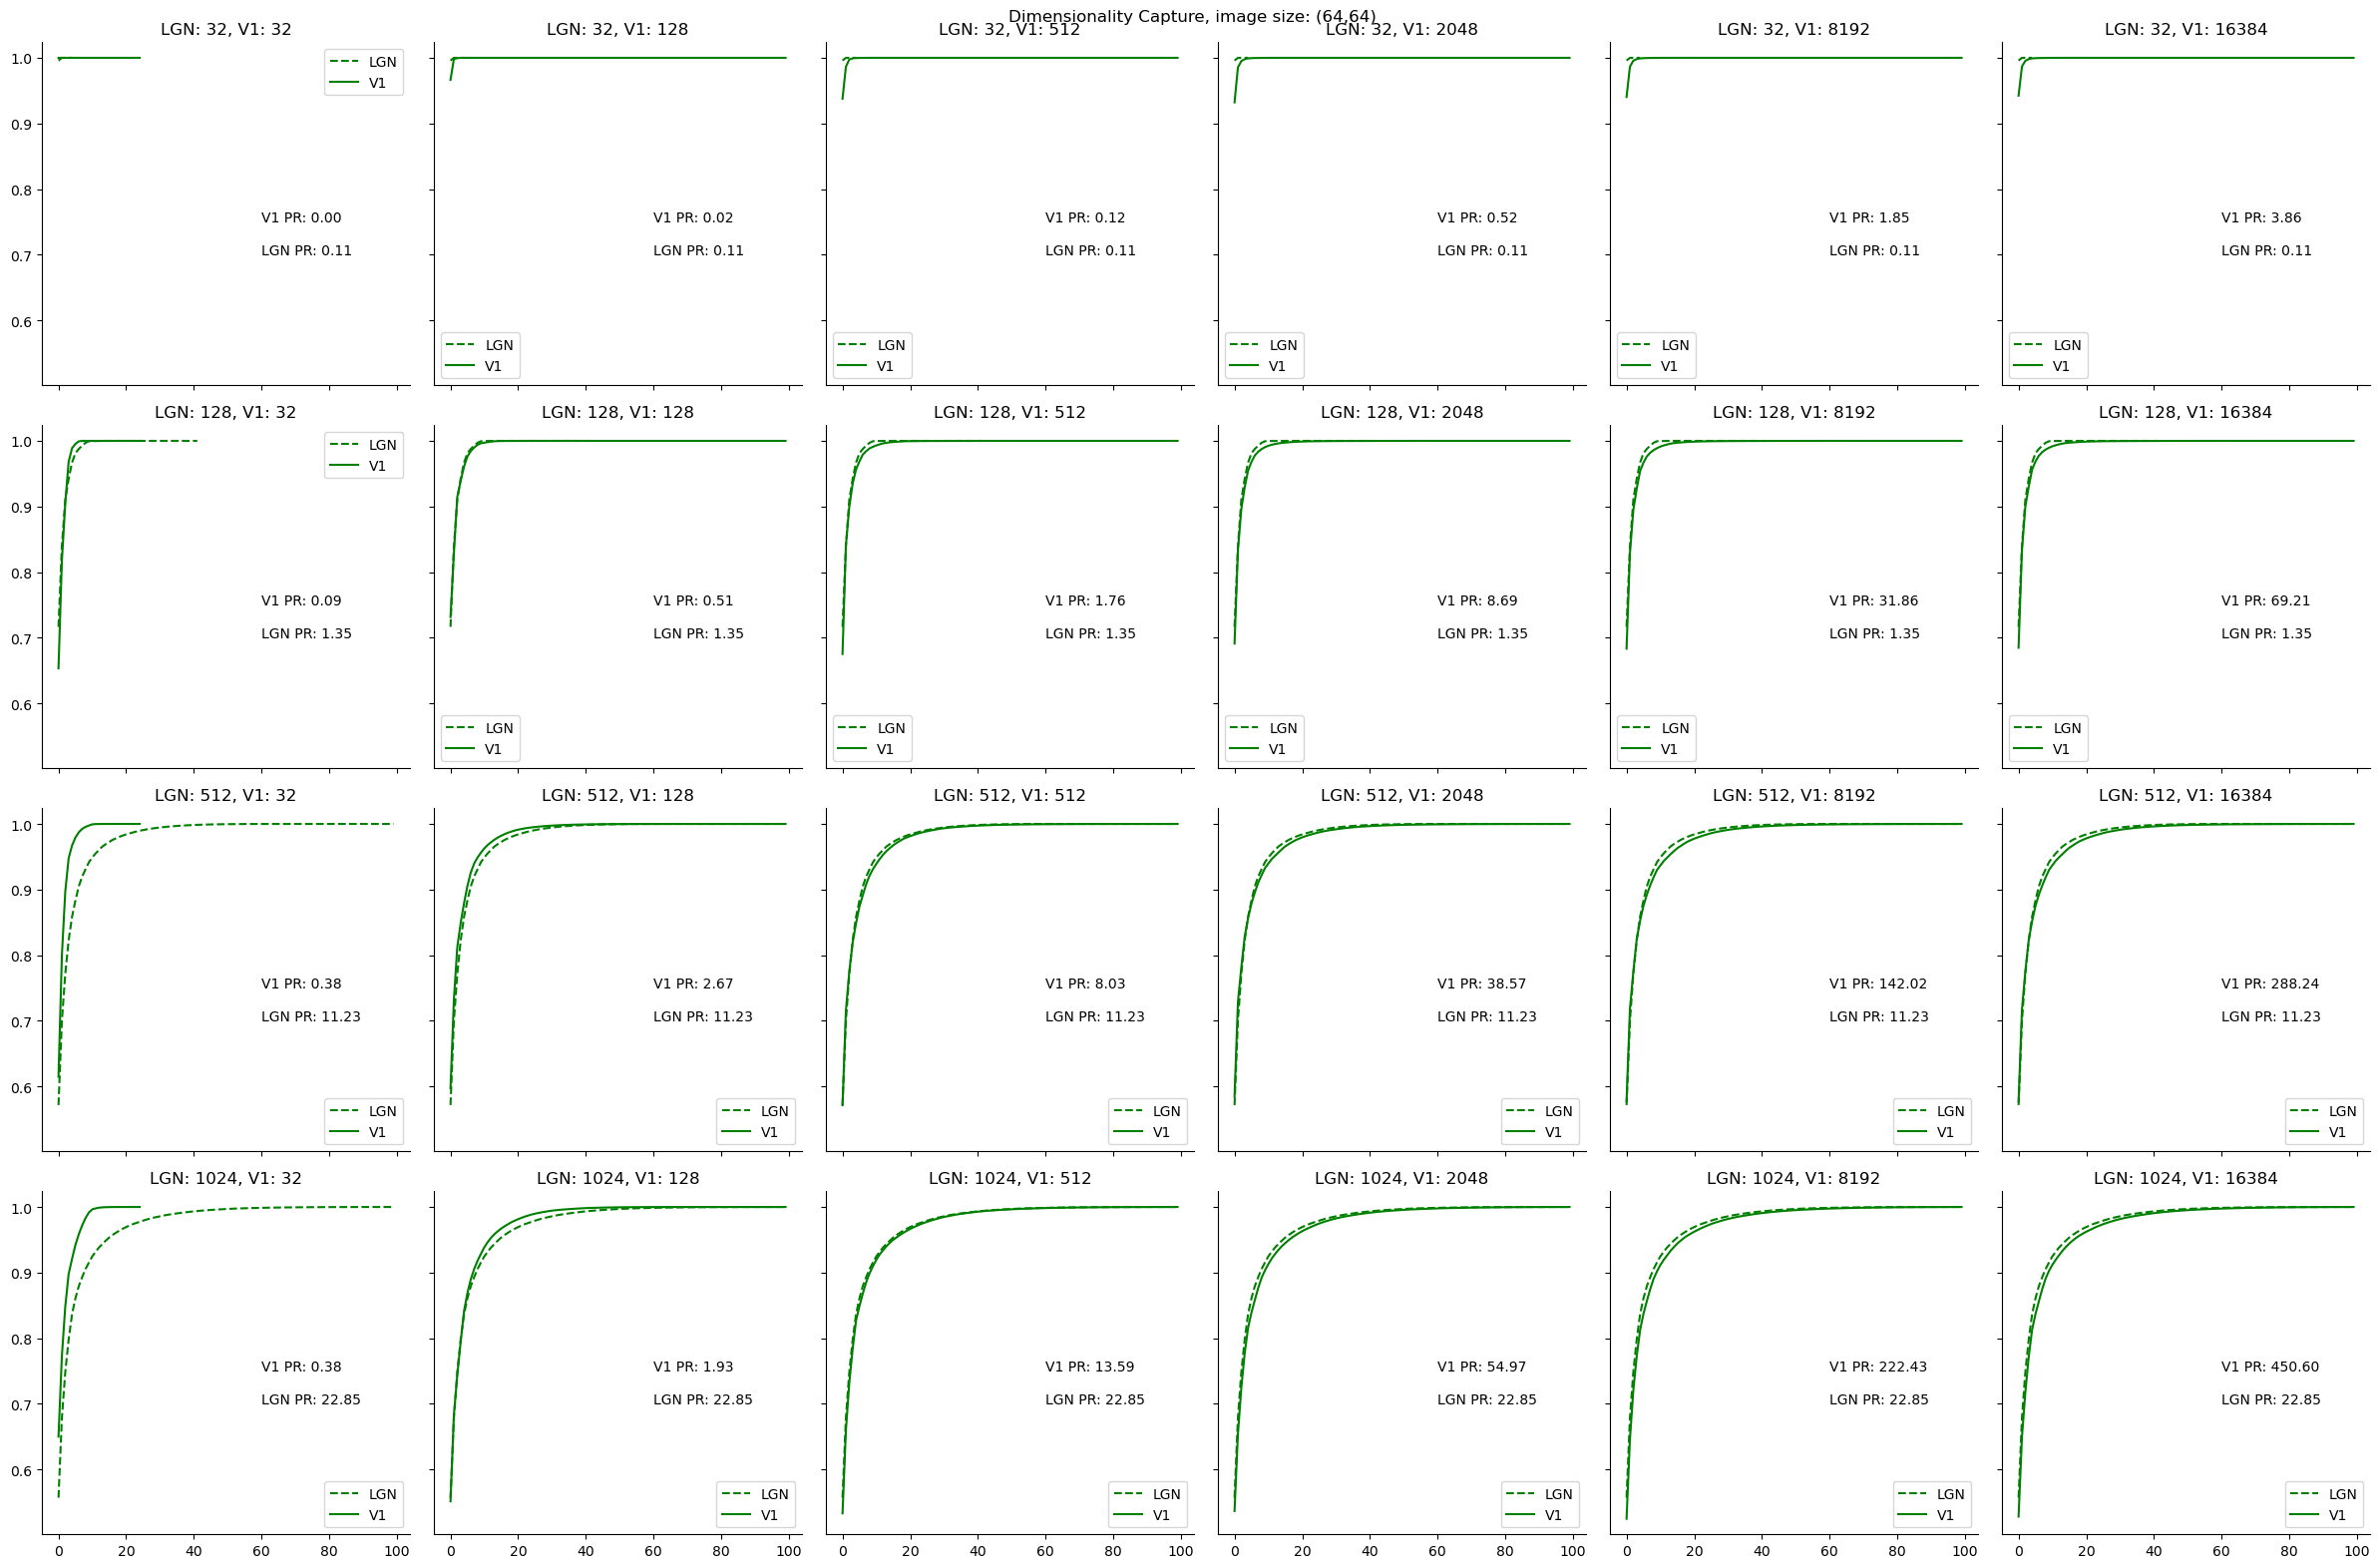

In [16]:
fig, ax = plt.subplots(4, 6, figsize=(24, 16), sharex=True, sharey=True)

l = [32, 128, 512, 1024]
v = [32, 128, 512, 2048, 8192, 16384]

stimuli = np.load("/u/home/s/skirti/scratch/dipoppa-lab/thalamocortical-expansion/01_data/natural_movies/IMG_3625_patches_64.npy")[:100,0]
L_pr = []

for i,a in enumerate(ax.flatten()):
    
    analyze_geometry(l[i // len(v)], v[i % len(v)], trained=False, ax=a, stimuli=stimuli, shape=(64,64))
    
fig.suptitle("Dimensionality Capture, image size: (64,64)")
fig.set_tight_layout(True)
plt.show()

In [19]:
def analyze_geometry(lgn, v1, trained, stimuli, shape=(224,224)):

    # get the model
    data = get_full_model_data(lgn, v1, trained, shape=shape)
    if not data:
        return None

    model, _, weights, _ = data

    l_res, v_res = [], []
    for i in range(len(stimuli)):
        _, l, v = model.forward(stimuli[i], weights=jnp.array(weights))
        l_res.append(np.array(l))
        v_res.append(np.array(v))

    L = np.array(l_res)
    V = np.array(v_res)

    # PCA
    L_pca = PCA().fit(L)
    V_pca = PCA().fit(V)

    # eigenvalues
    L_eig = L_pca.explained_variance_
    V_eig = V_pca.explained_variance_

    # participation ratio
    L_pr = (np.sum(L_eig) ** 2) / np.sum(L_eig ** 2)
    V_pr = (np.sum(V_eig) ** 2) / np.sum(V_eig ** 2)

    return {
        "LGN": lgn,
        "V1": v1,
        "LGN_PR": L_pr,
        "V1_PR": V_pr
    }

In [21]:
lgn_sizes = [32, 64, 128, 256, 512, 1024]
v1_sizes = [32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384]

stimuli = np.load(
    "/u/home/s/skirti/scratch/dipoppa-lab/thalamocortical-expansion/01_data/natural_movies/IMG_3625_patches.npy"
)[:100,0]

results = []

for lgn in lgn_sizes:
    for v1 in v1_sizes:

        res = analyze_geometry(lgn, v1, trained=False, stimuli=stimuli, shape=(224,224))

        if res is not None:
            results.append(res)

df_pr_224 = pd.DataFrame(results)

In [22]:
lgn_sizes = [32, 64, 128, 256, 512, 1024]
v1_sizes = [32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384]

stimuli = np.load(
    "/u/home/s/skirti/scratch/dipoppa-lab/thalamocortical-expansion/01_data/natural_movies/IMG_3625_patches_64.npy"
)[:100,0]

results = []

for lgn in lgn_sizes:
    for v1 in v1_sizes:

        res = analyze_geometry(lgn, v1, trained=False, stimuli=stimuli, shape=(64,64))

        if res is not None:
            results.append(res)

df_pr_64 = pd.DataFrame(results)

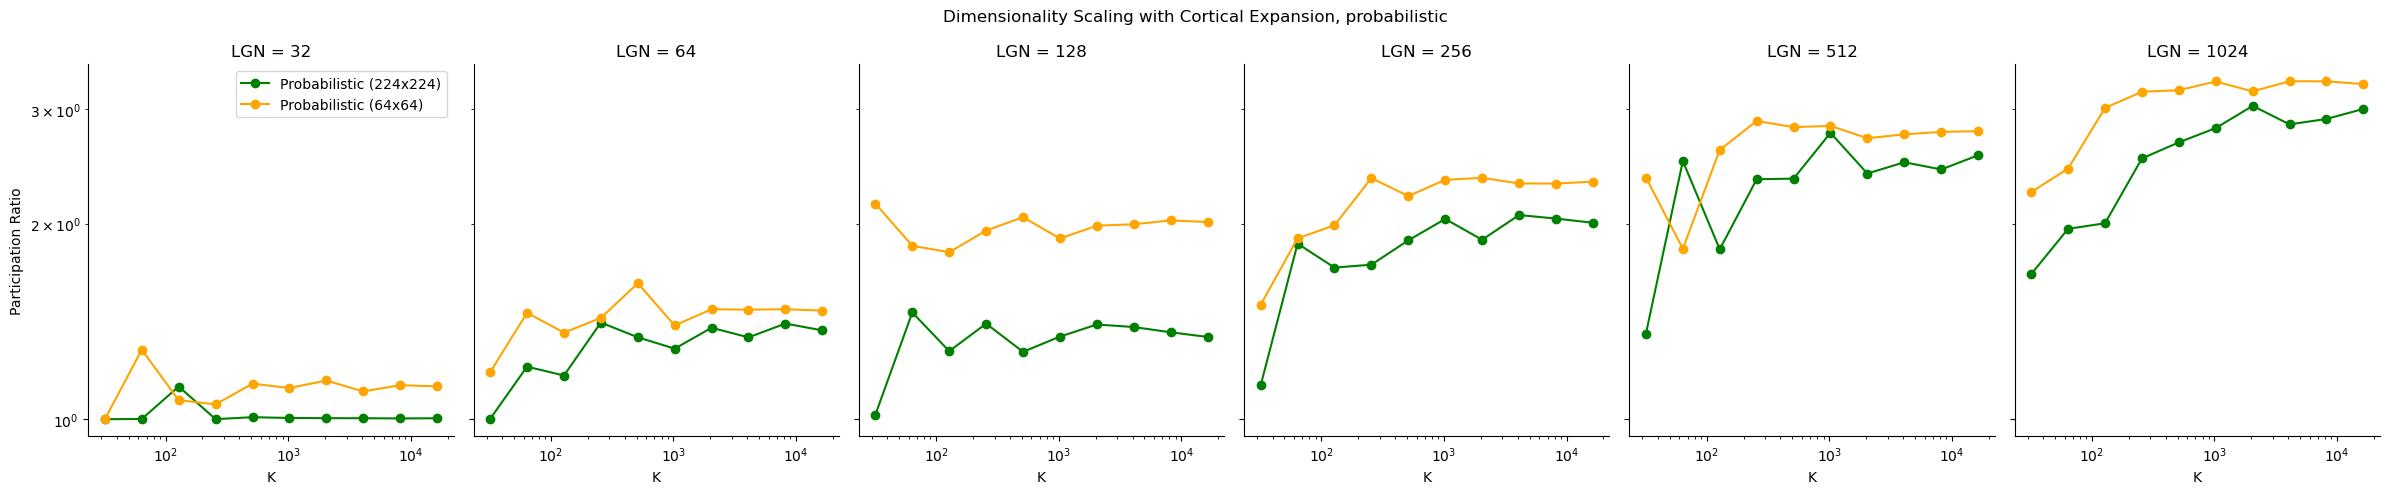

In [23]:
fig, axes = plt.subplots(1, len(lgn_sizes), figsize=(24,5), sharey=True)

for i, lgn in enumerate(lgn_sizes):

    ax = axes[i]

    sub_224 = df_pr_224[df_pr_224["LGN"] == lgn].sort_values("V1")
    sub_64 = df_pr_64[df_pr_64["LGN"] == lgn].sort_values("V1")

    ax.plot(sub_224["V1"], sub_224["V1_PR"], "o-", label="Probabilistic (224x224)", color="green")
    ax.plot(sub_64["V1"], sub_64["V1_PR"], "o-", label="Probabilistic (64x64)", color="orange")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(f"LGN = {lgn}")
    ax.set_xlabel("K")

    if i == 0:
        ax.set_ylabel("Participation Ratio")
        ax.legend()

fig.suptitle("Dimensionality Scaling with Cortical Expansion, probabilistic")

plt.tight_layout()
plt.show()

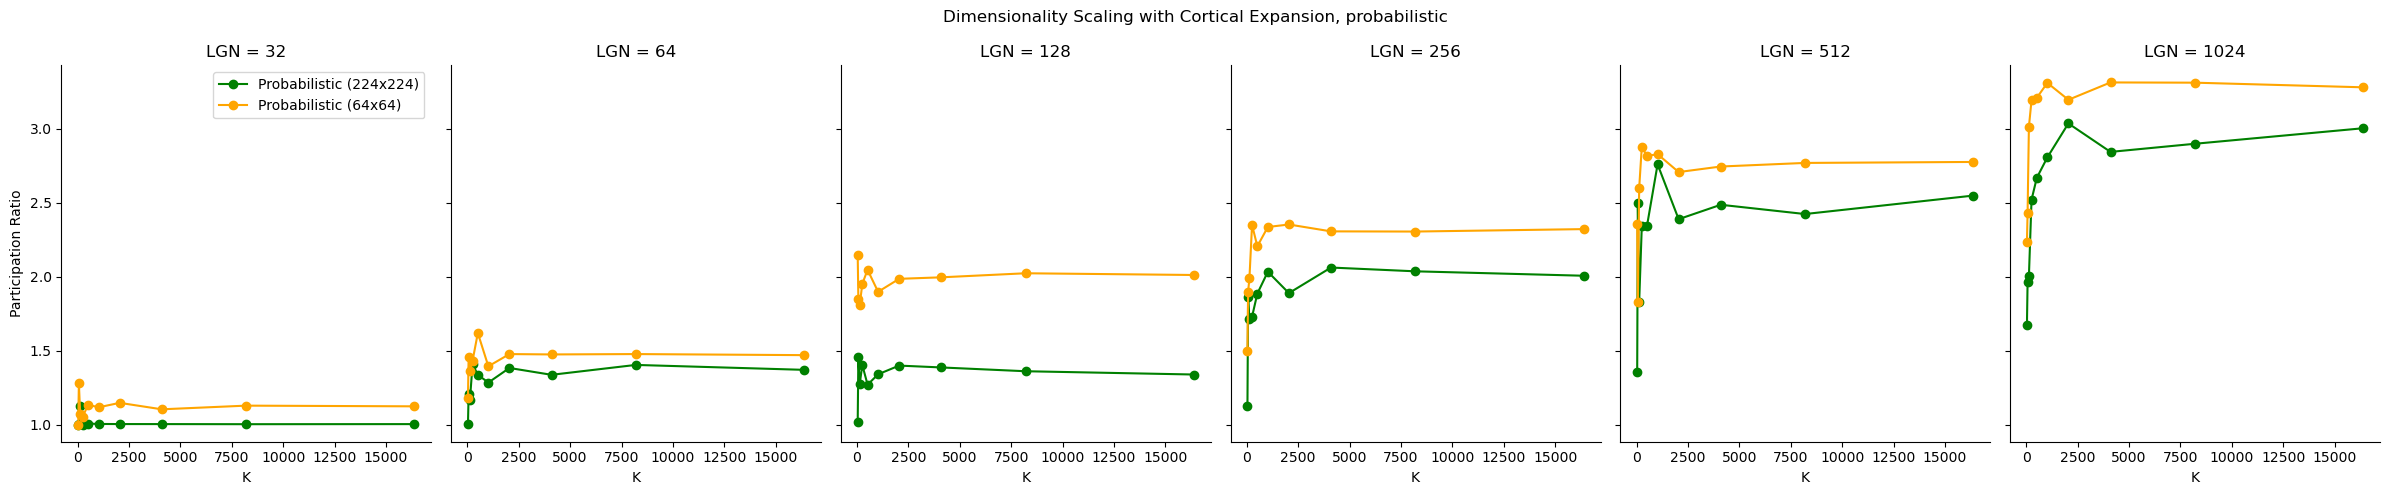

In [24]:
fig, axes = plt.subplots(1, len(lgn_sizes), figsize=(24,5), sharey=True)

for i, lgn in enumerate(lgn_sizes):

    ax = axes[i]

    sub_224 = df_pr_224[df_pr_224["LGN"] == lgn].sort_values("V1")
    sub_64 = df_pr_64[df_pr_64["LGN"] == lgn].sort_values("V1")

    ax.plot(sub_224["V1"], sub_224["V1_PR"], "o-", label="Probabilistic (224x224)", color="green")
    ax.plot(sub_64["V1"], sub_64["V1_PR"], "o-", label="Probabilistic (64x64)", color="orange")

    #ax.set_xscale("log")
    #ax.set_yscale("log")
    ax.set_title(f"LGN = {lgn}")
    ax.set_xlabel("K")

    if i == 0:
        ax.set_ylabel("Participation Ratio")
        ax.legend()

fig.suptitle("Dimensionality Scaling with Cortical Expansion, probabilistic")

plt.tight_layout()
plt.show()

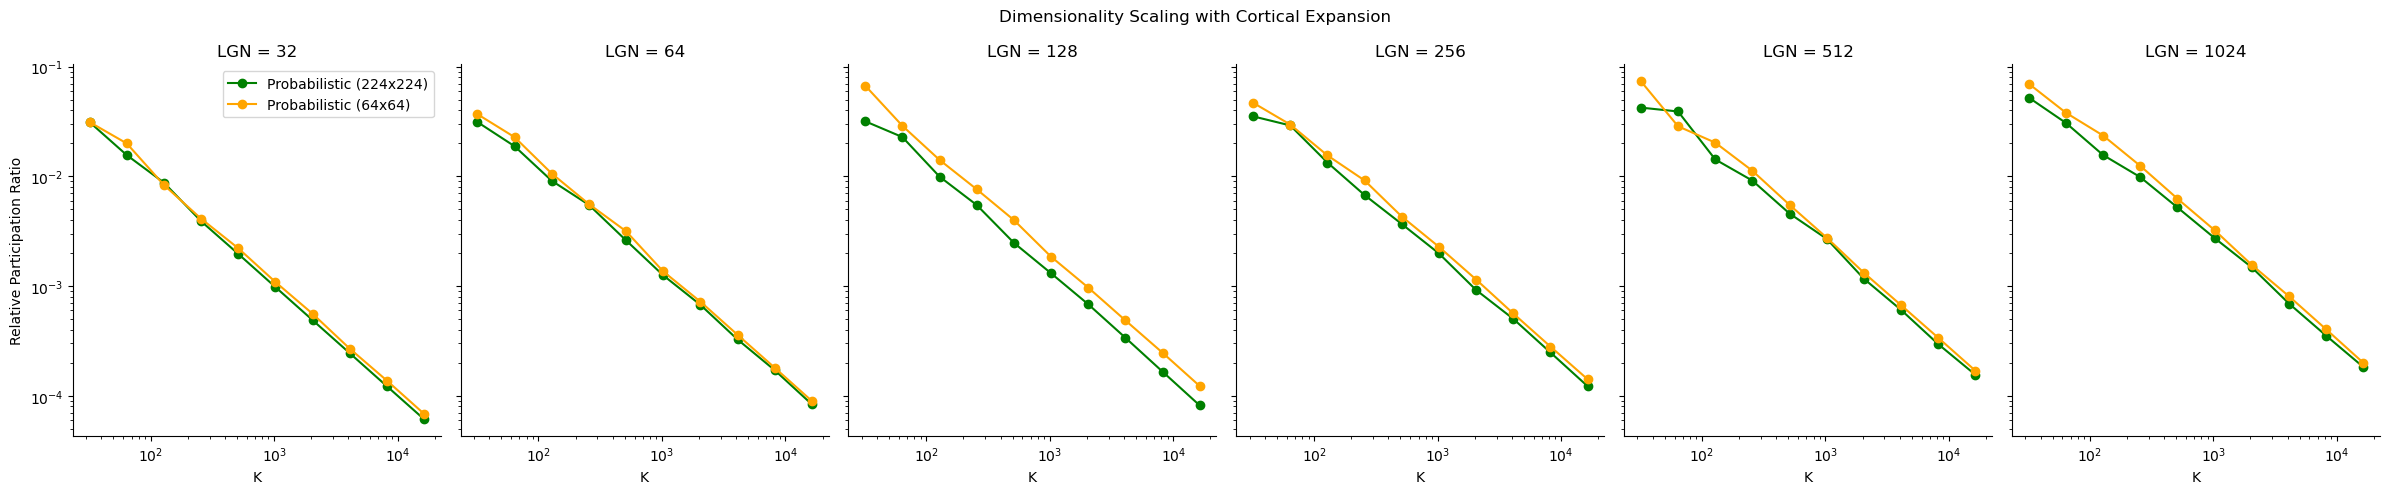

In [28]:
fig, axes = plt.subplots(1, len(lgn_sizes), figsize=(24,5), sharey=True)

for i, lgn in enumerate(lgn_sizes):

    ax = axes[i]

    sub_224 = df_pr_224[df_pr_224["LGN"] == lgn].sort_values("V1")
    sub_64 = df_pr_64[df_pr_64["LGN"] == lgn].sort_values("V1")

    ax.plot(sub_224["V1"], sub_224["V1_PR"] / sub_224["V1"], "o-", label="Probabilistic (224x224)", color="green")
    ax.plot(sub_64["V1"], sub_64["V1_PR"] / sub_64["V1"], "o-", label="Probabilistic (64x64)", color="orange")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(f"LGN = {lgn}")
    ax.set_xlabel("K")

    if i == 0:
        ax.set_ylabel("Relative Participation Ratio")
        ax.legend()

fig.suptitle("Dimensionality Scaling with Cortical Expansion")

plt.tight_layout()
plt.show()

## 8. Robustness & Ablation

Goal: Measure model performance degradation under LGN cell dropout.

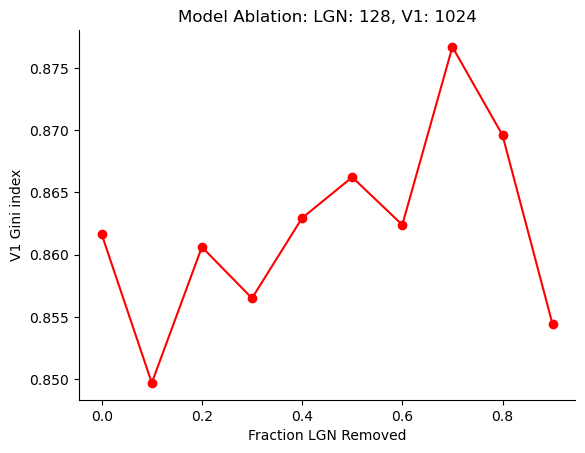

In [42]:
def analyze_ablation(lgn, v1):
    data = get_full_model_data(lgn, v1, True)
    if not data: return
    _, lgn_locs, weights, _ = data
    drop_levels = np.linspace(0, 0.9, 10)
    sig = []
    for d in drop_levels:
        w_drop = weights.copy()
        w_drop[:, np.random.rand(weights.shape[1]) < d] = 0
        sig.append(Utils.gini(np.mean(np.abs(w_drop @ np.random.randn(len(lgn_locs), 20)), axis=1)))
    plt.plot(drop_levels, sig, 'o-r')

    plt.xlabel("Fraction LGN Removed")
    plt.ylabel("V1 Gini index")
    plt.title(f"Model Ablation: LGN: {lgn}, V1: {v1}")
    plt.show()

analyze_ablation(128, 1024)

## 9. Orientation Selectivity

Goal: Detect emergent Gabor-like tuning curves for sinusoidal stimuli.

In [43]:
def analyze_tuning(lgn, v1, trained):

    data = get_full_model_data(lgn, v1, trained)
    if not data: return

    model, _, weights, _ = data
    angles = np.linspace(0, 2 * np.pi, 12)

    res = []
    fig, ax = plt.subplots(1, len(angles), figsize=(len(angles) * 4, 4))
    for i,a in enumerate(angles):
        x, y = np.meshgrid(np.arange(224), np.arange(224))
        stim = (np.sin(0.1 * (x*np.cos(a) + y*np.sin(a))) + 1)/2
        
        ax[i].imshow(stim)
        ax[i].axis("off")
        
        _, _, v = model.forward(jnp.array(stim), weights=jnp.array(weights))
        res.append(np.array(v))
    plt.show()

    R = np.array(res)
    top_n = np.argsort(np.max(R, axis=0))[-5:]

    plt.figure(figsize=(4 * len(angles), 16))
    for n in top_n:
        plt.plot(np.degrees(angles), R[:, n], 'o-', label=f"Unit {n}")

    plt.xlabel(r"$\theta$ (Deg)")
    plt.ylabel("V1 Response")
    plt.legend()
    plt.show()

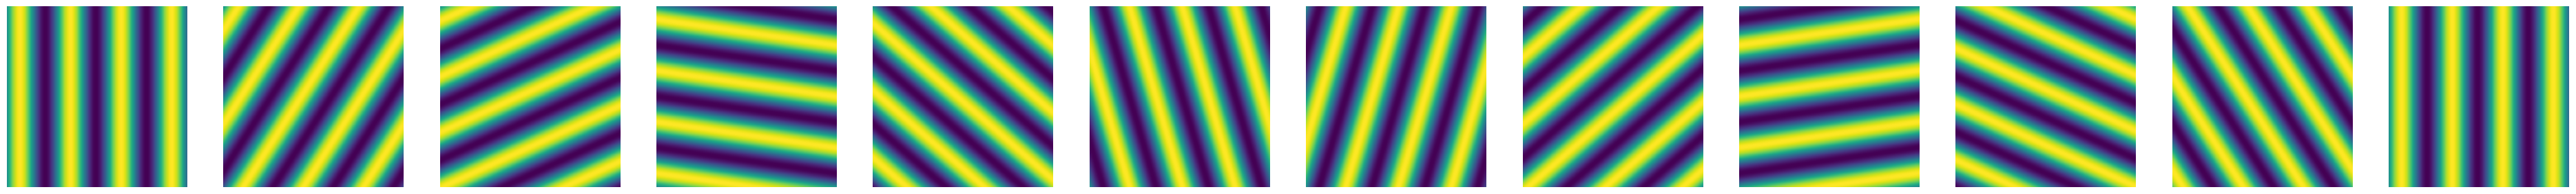

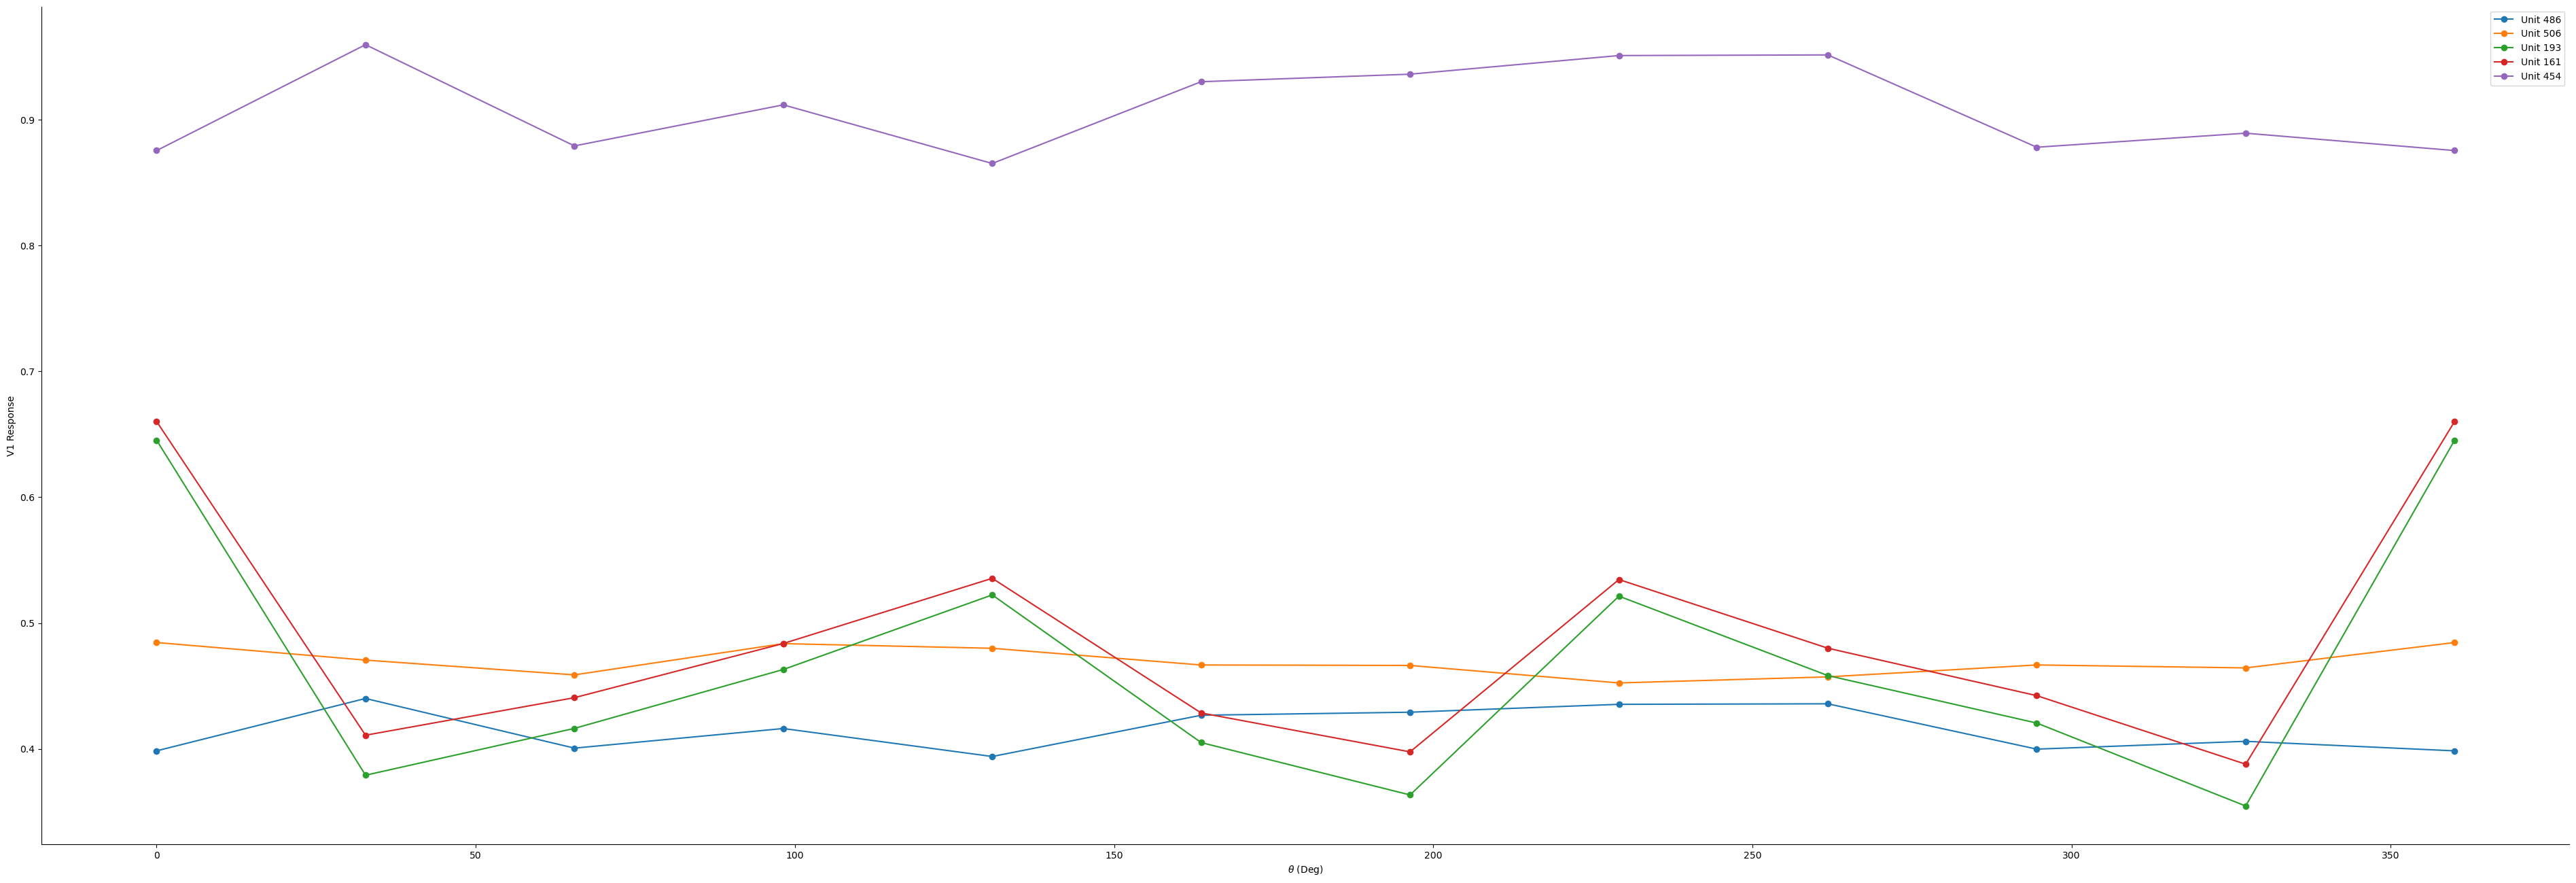

In [44]:
analyze_tuning(128, 1024, True)

In [45]:
# compute orientation selectivity index for this trained and for haphazard

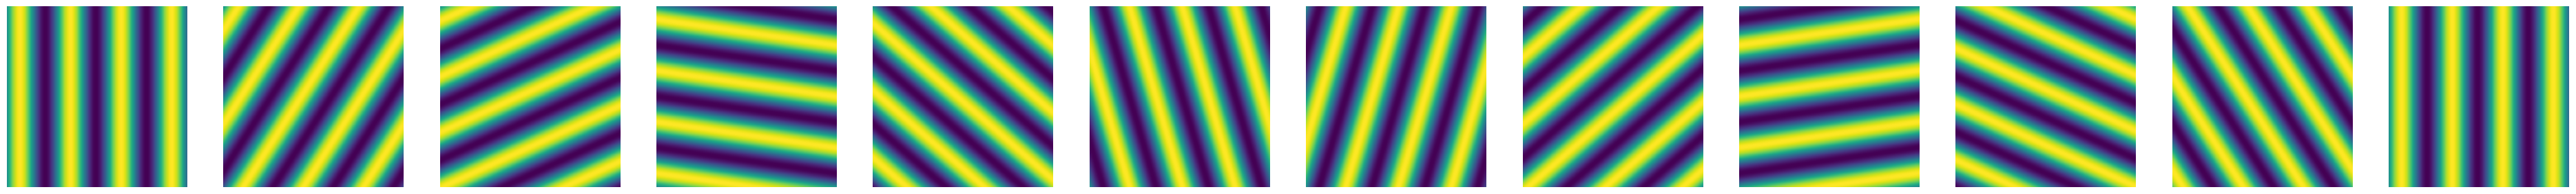

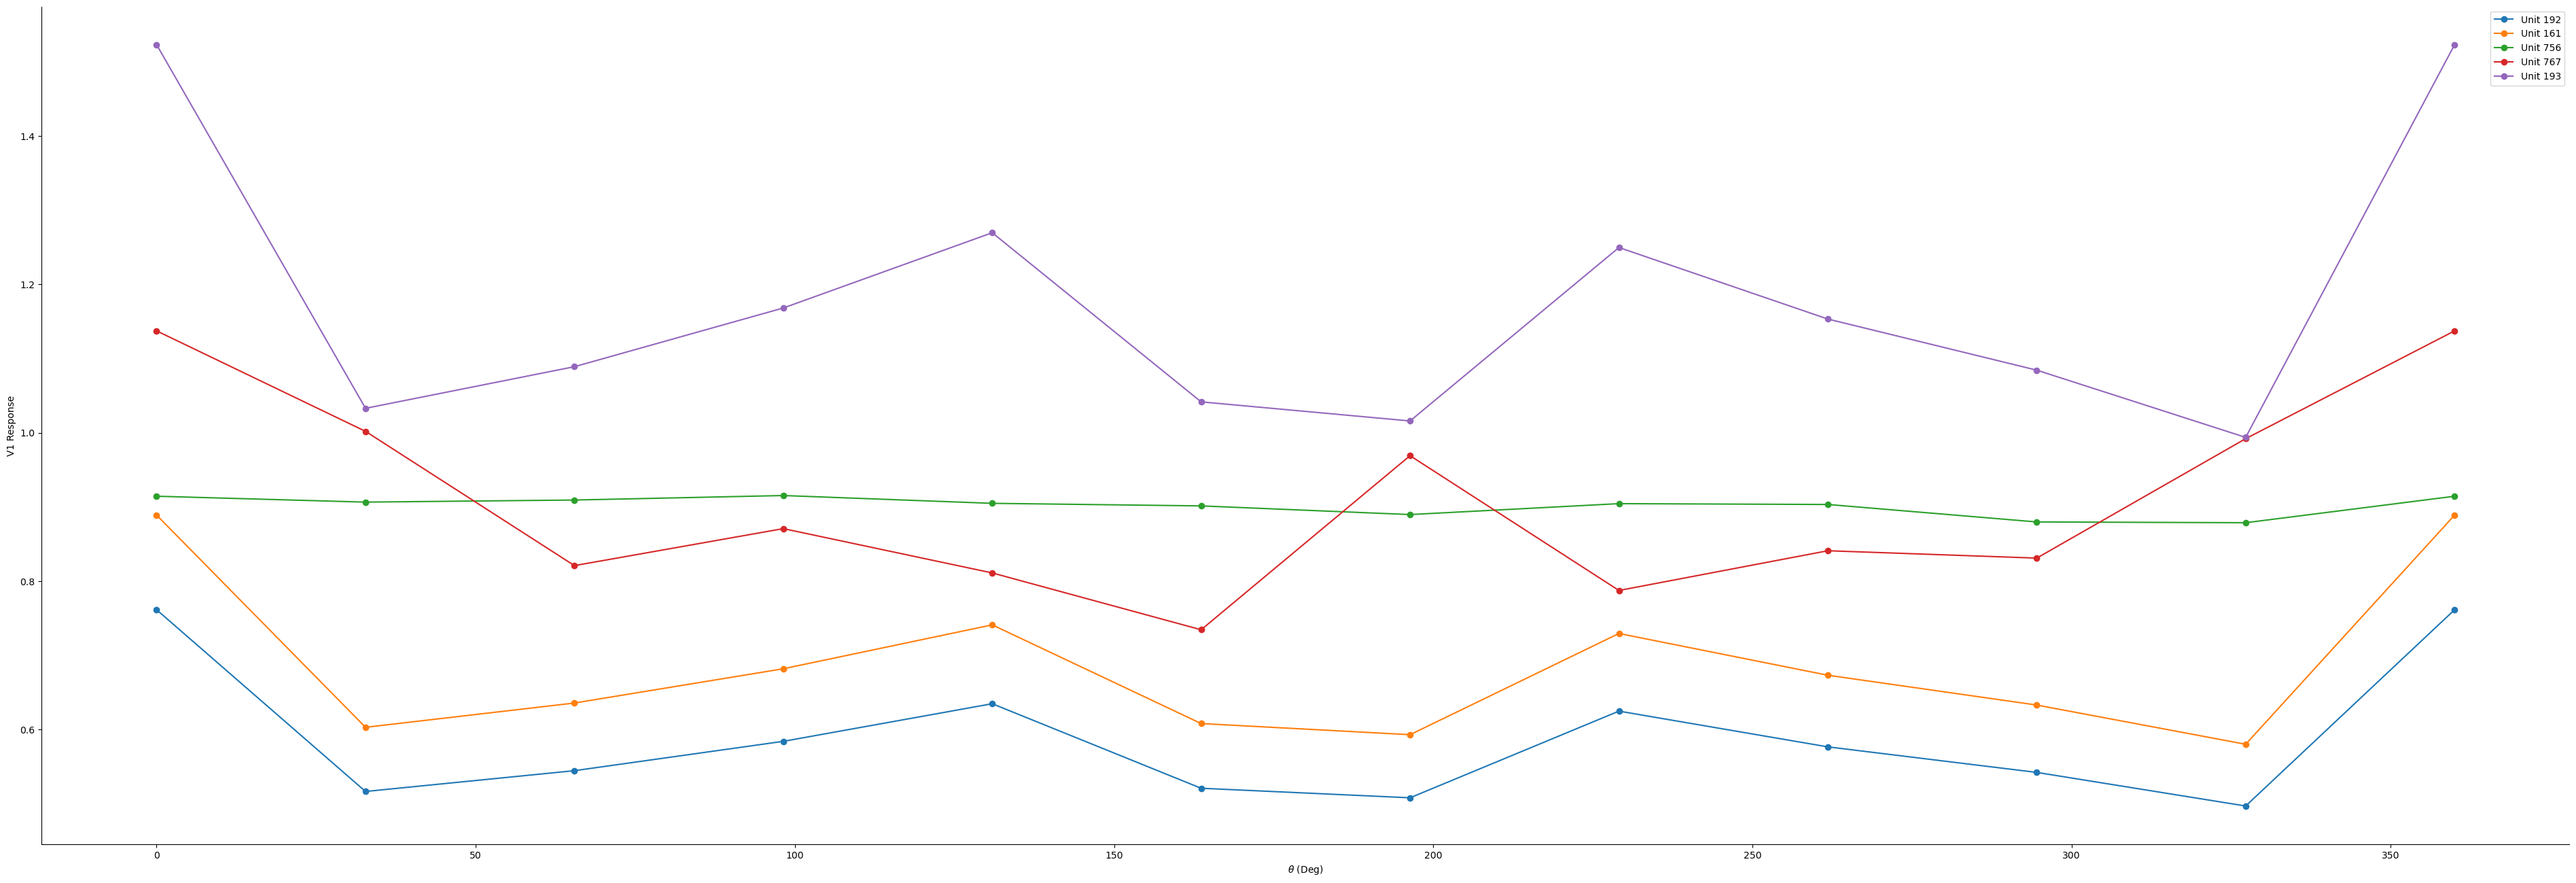

In [46]:
analyze_tuning(128, 1024, False)